In [1]:
from lbg_forecast.likelihood import Likelihood
import numpy as np
import matplotlib.pyplot as plt

import lbg_forecast.angular_power as ap
from scipy.optimize import minimize
from scipy.optimize import differential_evolution

path = "./"
lhood_mismatch_int = Likelihood(path)
lhood_mismatch_nag = Likelihood(path, mismatch_nag=True)

Initialising likelihood
Initialisation Complete
Initialising likelihood
Initialisation Complete


In [10]:
from scipy.optimize import minimize

def log_lhood(params, red):

    if((params < 0).any()):
        return -1e100
    else:
        mu = lhood_mismatch_int.mu_vec(params, red)
        d = lhood_mismatch_int.cl_mean
        inv_cov = lhood_mismatch_int._inv_C

        value = -0.5*(d - mu)@inv_cov@(d - mu).T

        if np.isnan(value) or np.isinf(value):
            return -1e100
        else:
            return value
  
fid_params = np.array([lhood_mismatch_int._cosmo_fid.sigma8, 
                    lhood_mismatch_int._cosmo_fid.Omega_c, lhood_mismatch_int._cosmo_fid.Omega_b,
                    lhood_mismatch_int._cosmo_fid.h, lhood_mismatch_int._cosmo_fid.n_s,
                    lhood_mismatch_int._b_lbg_u, lhood_mismatch_int._b_lbg_g, lhood_mismatch_int._b_lbg_r])

bounds = [(0, 100), 
          (0, 1),
          (0, 1),
          (0, 1),
          (0, 100),
          (0, 100),
          (0, 100),
          (0, 100)] 

reduced_list=[0.0]#[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results = []
p_diffs = []
for reduced in reduced_list: 
    print(reduced)
    res = minimize(lambda x, y=reduced: -log_lhood(x, y), fid_params, bounds=bounds, method='Nelder-Mead')
    p_diffs.append(((res.x - fid_params)/fid_params)*100)
    results.append(res.x)
    print(res.x)

#np.save('biases/results.npy', results)
#np.save('biases/pdiffs.npy', p_diffs)
#np.save('biases/grid.npy', reduced_list)


0.0
[0.79630586 0.28669695 0.04870766 0.63412839 0.97059262 2.89363366
 3.85680964 4.95499391]


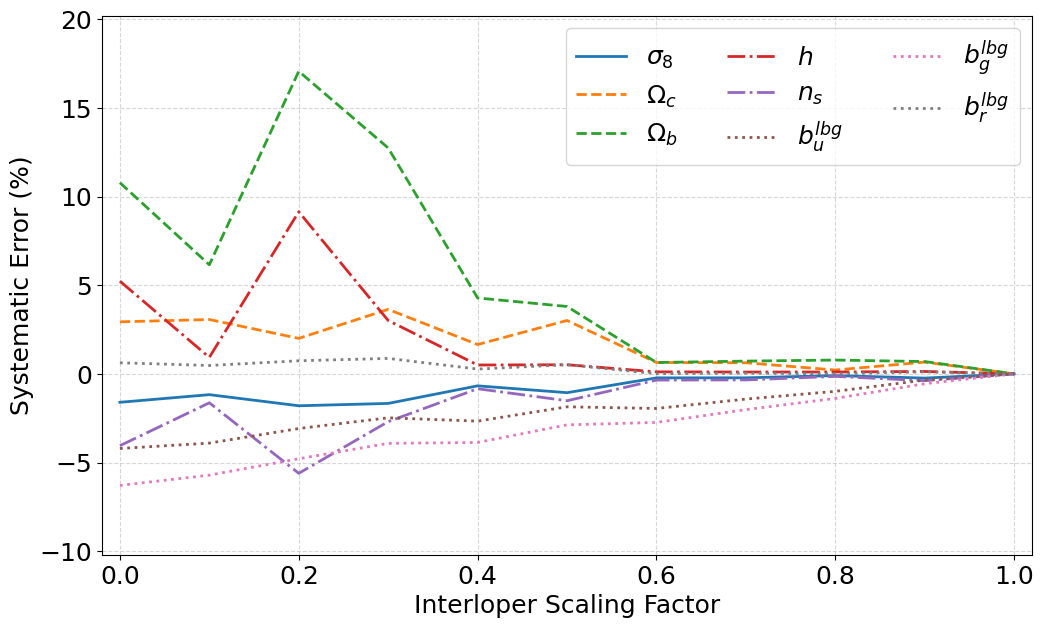

In [11]:
loaded_results = np.load('biases/results.npy')
loaded_pdiffs = np.load('biases/pdiffs.npy')
loaded_grid = np.load('biases/grid.npy')

labels = np.array(["$\sigma_{8}$", "$\Omega_{c}$", "$\Omega_{b}$",
                        "$h$", "$n_{s}$", "$b^{lbg}_{u}$", "$b^{lbg}_{g}$", "$b^{lbg}_{r}$"])
lss = ['-', "--", "--","-.", "-.", ":", ":", ":"]
init = loaded_results[-1, :]

f, ax = plt.subplots(1, 1, figsize=(12, 7))

for param in range(fid_params.shape[0]):
    ax.plot(loaded_grid, 100*(loaded_results[:, param] - loaded_results[-1, param])/loaded_results[-1, param], label=labels[param], ls=lss[param], lw=2)
ax.legend(ncols=3, fontsize=18)
fs=18

ax.grid(alpha=0.5, ls='--')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-10.2, 20.2)
ax.set_ylabel('Systematic Error (%)', fontsize=fs)
ax.set_xlabel('Interloper Scaling Factor', fontsize=fs)
ax.tick_params('x', labelsize=fs)
ax.tick_params('y', labelsize=fs)

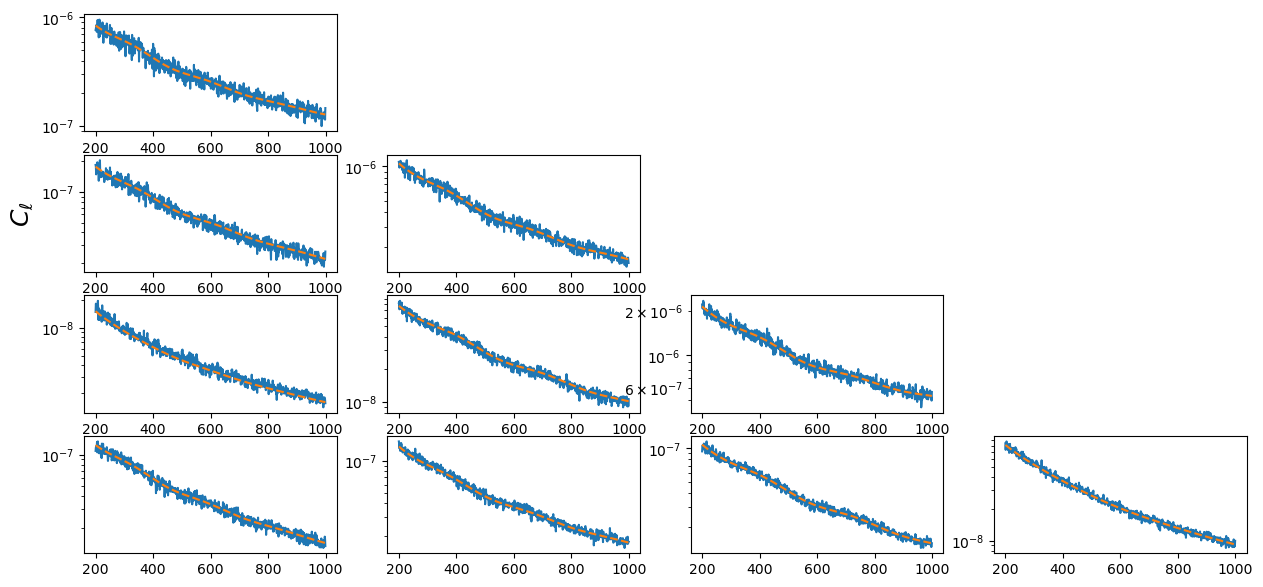

In [12]:
mu = lhood_mismatch_int.mu_vec(fid_params, 0.0)
mu_x = lhood_mismatch_int.mu_vec(res.x, 0.0)
d = lhood_mismatch_int.cl_mean
ap.compare_cls(d, mu_x, lhood_mismatch_int._ell, (15, 7), 18, 4)


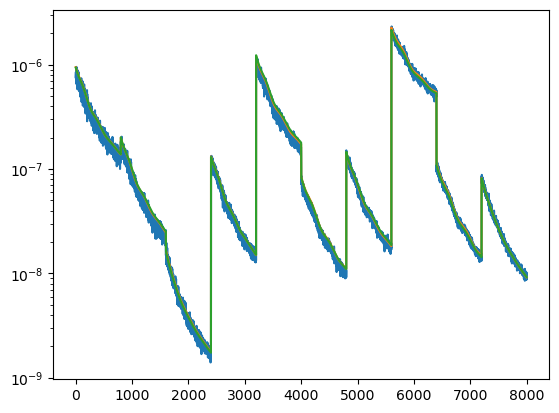

In [5]:
plt.plot(lhood_mismatch_int.cl_mean)
plt.plot(lhood_mismatch_int.mu_vec(fid_params, 0.0))
plt.plot(lhood_mismatch_int.mu_vec(res.x, 0.0))
plt.yscale('log')

In [6]:
from scipy.optimize import minimize

fid_params = np.array([lhood_mismatch_int._cosmo_fid.sigma8, 
                    lhood_mismatch_int._cosmo_fid.Omega_c, lhood_mismatch_int._cosmo_fid.Omega_b,
                    lhood_mismatch_int._cosmo_fid.h, lhood_mismatch_int._cosmo_fid.n_s,
                    lhood_mismatch_int._b_lbg_u, lhood_mismatch_int._b_lbg_g, lhood_mismatch_int._b_lbg_r])


bounds = [(0, 100), 
          (0, 1),
          (0, 1),
          (0, 1),
          (0, 100),
          (0, 100),
          (0, 100),
          (0, 100)] 

def log_lhood_nag(params):

    if((params < 0).any()):
        return -1e100
    else:
        mu = lhood_mismatch_nag.mu_vec_nag(params)
        d = lhood_mismatch_nag.cl_mean
        inv_cov = lhood_mismatch_nag._inv_C

        value = -0.5*(d - mu)@inv_cov@(d - mu).T

        if np.isnan(value) or np.isinf(value):
            return -1e100
        else:
            return value


res = minimize(lambda x: -log_lhood_nag(x), fid_params, bounds=bounds, method='Nelder-Mead')
print(res.x, fid_params, res.success, log_lhood_nag(fid_params), log_lhood_nag(res.x))
print('%: ', ((res.x - fid_params)/fid_params)*100)


[1.27254185e+00 4.37418246e-02 3.63282802e-02 7.09669692e-16
 2.42460618e+00 2.96504162e+00 3.47905721e+00 3.69507298e+00] [0.8159 0.2589 0.0486 0.6774 0.9667 3.     4.     5.    ] True -55929.74257350127 -20745.246724889996
%:  [  55.96786977  -83.10474138  -25.25045224 -100.          150.81268045
   -1.16527918  -13.02356985  -26.09854048]


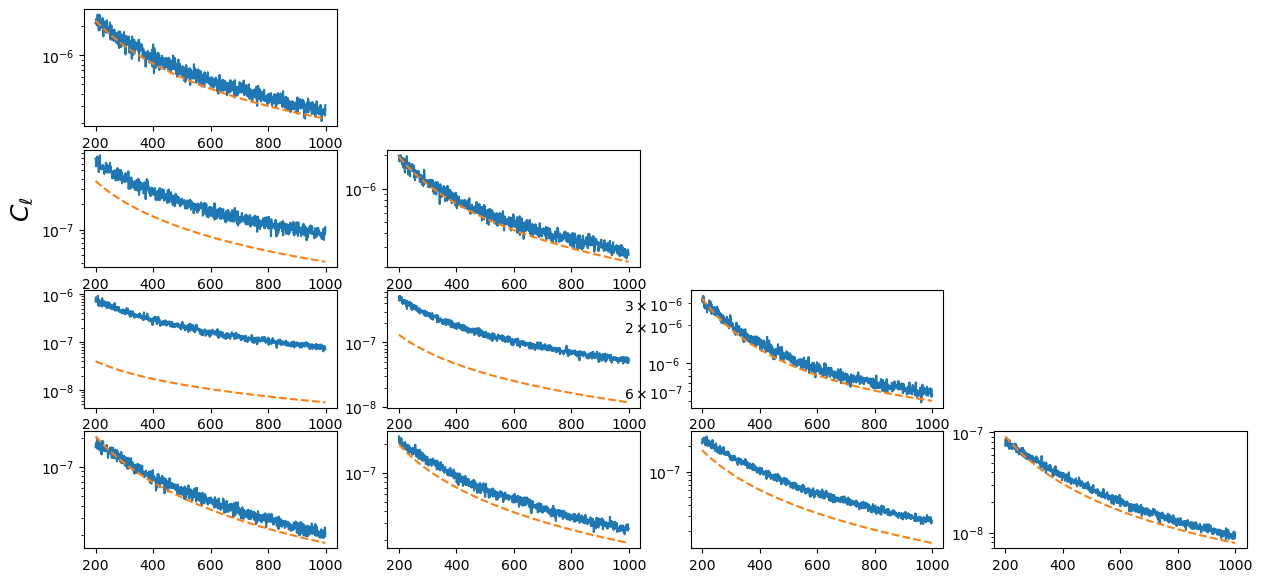

In [7]:
mu_x = lhood_mismatch_nag.mu_vec_nag(res.x)
mu_0 = lhood_mismatch_nag.mu_vec_nag(fid_params)
d = lhood_mismatch_nag.cl_mean
ap.compare_cls(d, mu_x, lhood_mismatch_nag._ell, (15, 7), 18, 4)

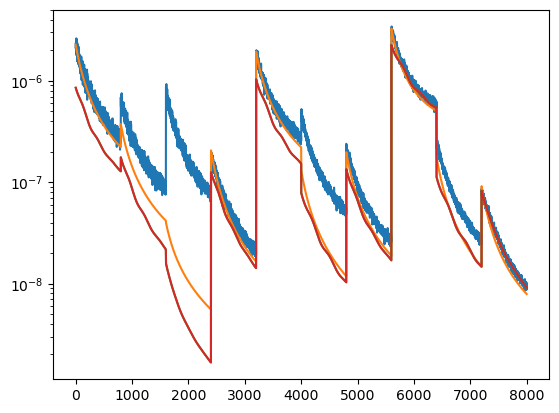

In [8]:
plt.plot(lhood_mismatch_nag.cl_mean)
plt.plot(lhood_mismatch_nag.mu_vec_nag(res.x))
plt.plot(lhood_mismatch_nag.mu_vec_nag(fid_params))
plt.plot(lhood_mismatch_int.mu_vec(fid_params, red=1.0))
plt.yscale('log')

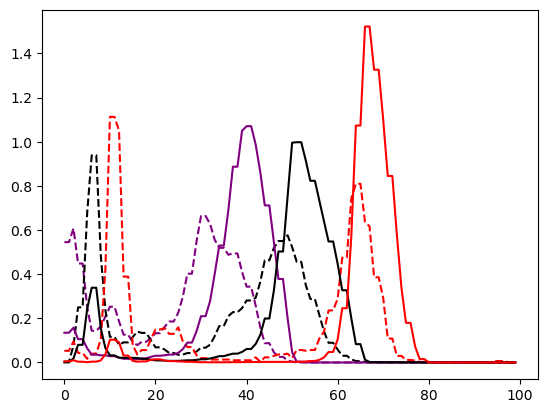

In [9]:
from lbg_forecast.modified_redshift import u_dropout
from lbg_forecast.modified_redshift import g_dropout
from lbg_forecast.modified_redshift import r_dropout
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from lbg_forecast.modified_redshift import u_dropout_nagaraj
from lbg_forecast.modified_redshift import g_dropout_nagaraj
from lbg_forecast.modified_redshift import r_dropout_nagaraj


mean_vec_u_nag = jnp.load("4pca_data/npca_means_u_nag.npy")
mean_vec_g_nag = jnp.load("4pca_data/npca_means_g_nag.npy")
mean_vec_r_nag = jnp.load("4pca_data/npca_means_r_nag.npy")

u_drop_nag = u_dropout_nagaraj(mean_vec_u_nag, red=1.0)
g_drop_nag = g_dropout_nagaraj(mean_vec_g_nag, red=1.0)
r_drop_nag = r_dropout_nagaraj(mean_vec_r_nag, red=1.0)


plt.plot(u_drop_nag(np.linspace(0, 7, 100)), color='purple', ls='--')
plt.plot(g_drop_nag(np.linspace(0, 7, 100)), color='black', ls='--')
plt.plot(r_drop_nag(np.linspace(0, 7, 100)), color='red', ls='--')

mean_vec_u = jnp.load("4pca_data/npca_means_u.npy")
mean_vec_g = jnp.load("4pca_data/npca_means_g.npy")
mean_vec_r = jnp.load("4pca_data/npca_means_r.npy")

u_drop = u_dropout(mean_vec_u, red=1.0)
g_drop = g_dropout(mean_vec_g, red=1.0)
r_drop = r_dropout(mean_vec_r, red=1.0)


plt.plot(u_drop(np.linspace(0, 7, 100)), color='purple')
plt.plot(g_drop(np.linspace(0, 7, 100)), color='black')
plt.plot(r_drop(np.linspace(0, 7, 100)), color='red')


import numpy as np
import emcee
import matplotlib.pyplot as plt

fid_params = np.array([lhood_mismatch_int._cosmo_fid.sigma8, 
                    lhood_mismatch_int._cosmo_fid.Omega_c, lhood_mismatch_int._cosmo_fid.Omega_b,
                    lhood_mismatch_int._cosmo_fid.h, lhood_mismatch_int._cosmo_fid.n_s,
                    lhood_mismatch_int._b_lbg_u, lhood_mismatch_int._b_lbg_g, lhood_mismatch_int._b_lbg_r])

bounds = [(0, 100), 
          (0, 1),
          (0, 1),
          (0, 1),
          (0, 100),
          (0, 100),
          (0, 100),
          (0, 100)] 

def log_lhood(params):

    if((params < 0).any()):
        return -np.inf
    else:
        mu = lhood_mismatch_int.mu_vec_noint(params)
        d = lhood_mismatch_int.cl_mean
        inv_cov = lhood_mismatch_int._inv_C

        value = -0.5*(d - mu)@inv_cov@(d - mu).T

        if np.isnan(value) or np.isinf(value):
            return -np.inf
        else:
            return value

ndim = fid_params.shape[0]
nwalkers = 100
nsteps = 300

# Initialize walkers in a small Gaussian ball around mu
p0 = fid_params + 1e-5 * np.random.randn(nwalkers, ndim)

# Run sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_lhood)
sampler.run_mcmc(p0, nsteps, progress=True)

# Get chain of samples
samples = sampler.get_chain(discard=0, flat=True)

# Plot
plt.figure(figsize=(6,6))
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.5)
plt.xlabel("theta[0]")
plt.ylabel("theta[1]")
plt.title("emcee MCMC samples")
plt.show()

samples_chain = sampler.get_chain()   # shape (nsteps, nwalkers, ndim)

fig, axes = plt.subplots(ndim, figsize=(10, 20), sharex=True)
for i in range(ndim):
    for w in range(nwalkers):
        axes[i].plot(samples_chain[:, w, i], alpha=0.5)
    axes[i].set_ylabel(f"theta[{i}]")
axes[-1].set_xlabel("step")
plt.show()

np.mean(samples, axis=0), fid_params